# Predicción de Suscripción a Depósitos Bancarios mediante Aprendizaje Automático Supervisado

## 0. Configuración y reproducibilidad

In [ ]:
from pathlib import Path
import zipfile, warnings, sys, platform, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 130

NAVY, GOLD, GREEN, GREY, RED = '#1F3864', '#C9A227', '#2E8B57', '#9AA0A6', '#C0392B'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'font.size': 11})

FIG_DIR = Path('figuras_paper'); FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path('modelos'); MODEL_DIR.mkdir(exist_ok=True)

def guardar_fig(nombre):
    '''Guarda la figura actual en figuras_paper/ para incorporarla al paper.'''
    plt.savefig(FIG_DIR / f'{nombre}.png', bbox_inches='tight', dpi=160, facecolor='white')

print('Python', sys.version.split()[0], '|', platform.system())
print('Semilla global:', RANDOM_STATE)

Python 3.12.4 | Windows
Semilla global: 42


## 1. Carga, inventario y selección del dataset

In [4]:
# Localización y extracción robusta de los datos

BASE_DIR = Path('bank_marketing_data')
BASE_DIR.mkdir(exist_ok=True)

def localizar_csvs():
    return sorted(set(Path('.').rglob('bank*additional*full.csv')) |
                  set(BASE_DIR.rglob('*.csv')))

if not localizar_csvs():
    zips = list(Path('.').rglob('*bank*marketing*.zip')) + list(Path('.').rglob('bank*additional*.zip'))
    if not zips:
        raise FileNotFoundError(
            'No se encontraron CSV ni ZIP de Bank Marketing. '
            'Coloca el archivo bank_marketing.zip en la carpeta del notebook.')
    for z in zips:
        with zipfile.ZipFile(z) as zf:
            zf.extractall(BASE_DIR)
    for nz in BASE_DIR.rglob('*.zip'):
        with zipfile.ZipFile(nz) as zf:
            zf.extractall(nz.with_suffix(''))

csv_paths = localizar_csvs()
print('CSV encontrados:')
for p in csv_paths:
    print('  -', p, f'({p.stat().st_size/1024:.0f} KB)')

CSV encontrados:
  - bank_marketing_data\bank\bank-full.csv (4502 KB)
  - bank_marketing_data\bank\bank.csv (451 KB)
  - bank_marketing_data\bank-additional\bank-additional\bank-additional-full.csv (5698 KB)
  - bank_marketing_data\bank-additional\bank-additional\bank-additional.csv (570 KB)


In [5]:
# Perfil comparativo de las versiones del dataset

datasets = {}
for path in csv_paths:
    try:
        datasets[path.name] = pd.read_csv(path, sep=';')
    except Exception as e:
        print('No se pudo leer', path, e)

filas = []
for nombre, d in datasets.items():
    unk = sum((d[c].astype(str).str.lower() == 'unknown').sum()
              for c in d.select_dtypes(include='object').columns)
    filas.append({
        'dataset': nombre,
        'filas': d.shape[0], 'columnas': d.shape[1],
        'nulos': int(d.isna().sum().sum()),
        'unknown': int(unk),
        'duplicados': int(d.duplicated().sum()),
        'tiene_y': 'y' in d.columns,
    })
comparativo = pd.DataFrame(filas).sort_values(['columnas', 'filas'], ascending=False).reset_index(drop=True)
comparativo

,dataset,filas,columnas,nulos,unknown,duplicados,tiene_y
0,bank-additional-full.csv,41188,21,0,12718,12,True
1,bank-additional.csv,4119,21,0,1230,0,True
2,bank-full.csv,45211,17,0,52124,0,True
3,bank.csv,4521,17,0,5254,0,True


In [6]:
DATASET_PRINCIPAL = 'bank-additional-full.csv'
assert DATASET_PRINCIPAL in datasets, f'No se encontró {DATASET_PRINCIPAL}'
df_raw = datasets[DATASET_PRINCIPAL].copy()
print(f'Dataset principal: {DATASET_PRINCIPAL}  ->  {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
df_raw.head()

Dataset principal: bank-additional-full.csv  ->  41,188 filas x 21 columnas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. EDA

In [7]:
# Tipos de variable y agrupación conceptual

info_vars = pd.DataFrame({
    'variable': df_raw.columns,
    'tipo': [str(df_raw[c].dtype) for c in df_raw.columns],
    'n_unicos': [df_raw[c].nunique() for c in df_raw.columns],
    'nulos': [int(df_raw[c].isna().sum()) for c in df_raw.columns],
})

grupos = {
    'Cliente': ['age','job','marital','education','default','housing','loan'],
    'Contacto y campaña': ['contact','month','day_of_week','duration','campaign','pdays','previous','poutcome'],
    'Contexto socioeconómico': ['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed'],
    'Objetivo': ['y'],
}
info_vars['grupo'] = info_vars['variable'].map({v:g for g,vs in grupos.items() for v in vs})
info_vars

,variable,tipo,n_unicos,nulos,grupo
0,age,int64,78,0,Cliente
1,job,object,12,0,Cliente
2,marital,object,4,0,Cliente
3,education,object,8,0,Cliente
4,default,object,3,0,Cliente
5,housing,object,3,0,Cliente
6,loan,object,3,0,Cliente
7,contact,object,2,0,Contacto y campaña
8,month,object,10,0,Contacto y campaña
9,day_of_week,object,5,0,Contacto y campaña


clase  cantidad  porcentaje
   no     36548       88.73
  yes      4640       11.27


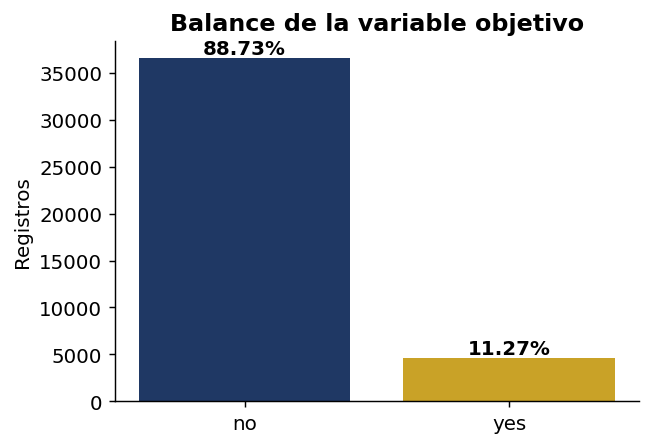

In [8]:
# Balance de la variable objetivo

balance = (df_raw['y'].value_counts().rename_axis('clase').reset_index(name='cantidad'))
balance['porcentaje'] = (balance['cantidad'] / len(df_raw) * 100).round(2)
print(balance.to_string(index=False))

fig, ax = plt.subplots(figsize=(5.2, 3.6))
bars = ax.bar(balance['clase'].astype(str), balance['cantidad'], color=[NAVY, GOLD])
ax.set_title('Balance de la variable objetivo'); ax.set_ylabel('Registros')
for b, pct in zip(bars, balance['porcentaje']):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{pct}%', ha='center', va='bottom', fontweight='bold')
guardar_fig('fig1_balance'); plt.show()

In [43]:
NUM_EDA = ['age','duration','campaign','pdays','previous',
           'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
CAT_EDA = ['job','marital','education','default','housing','loan',
           'contact','month','day_of_week','poutcome']

desc = df_raw[NUM_EDA].describe().T
desc['skew'] = df_raw[NUM_EDA].skew(numeric_only=True)
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00,0.78
duration,41188.0,258.29,259.28,0.00,102.00,180.00,319.00,4918.00,3.26
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00,4.76
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00,-4.92
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00,3.83
emp.var.rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40,-0.72
cons.price.idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77,-0.23
cons.conf.idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90,0.30
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04,-0.71
nr.employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10,-1.04


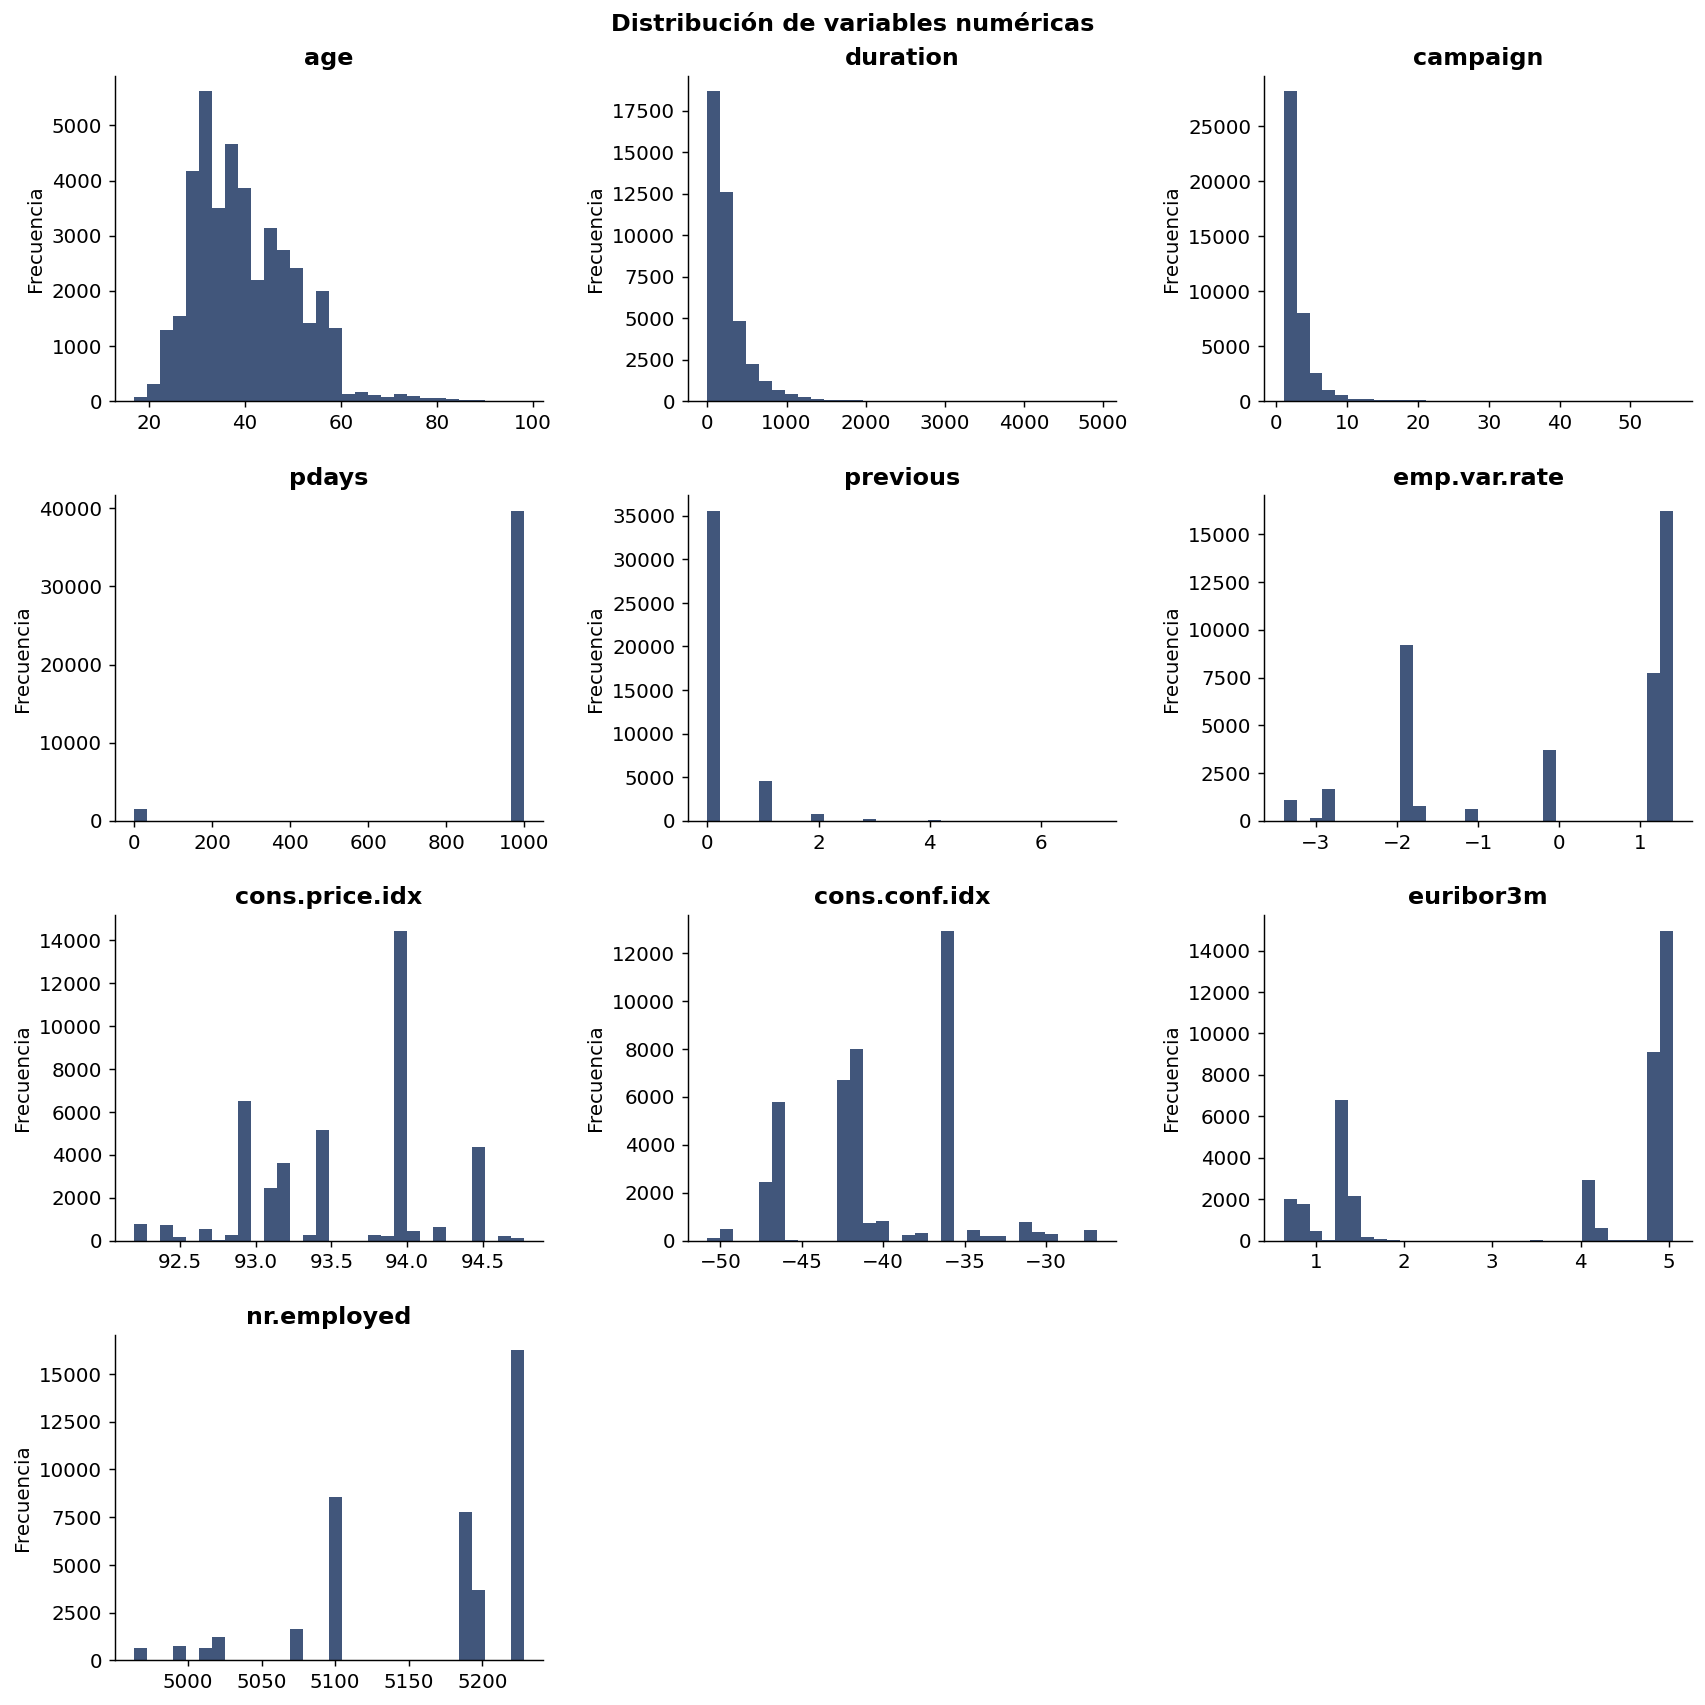

In [53]:
fig, axs = plt.subplots(4, 3, figsize=(13, 13), constrained_layout=True); axs = axs.ravel()
for k, c in enumerate(NUM_EDA):
    axs[k].hist(df_raw[c].dropna(), bins=30, color=NAVY, alpha=0.85)
    axs[k].set_title(c); axs[k].set_ylabel('Frecuencia')
for k in range(len(NUM_EDA), len(axs)): axs[k].axis('off')
fig.set_constrained_layout_pads(hspace=0.08, wspace=0.06)
fig.suptitle('Distribución de variables numéricas', fontweight='bold')
plt.show()

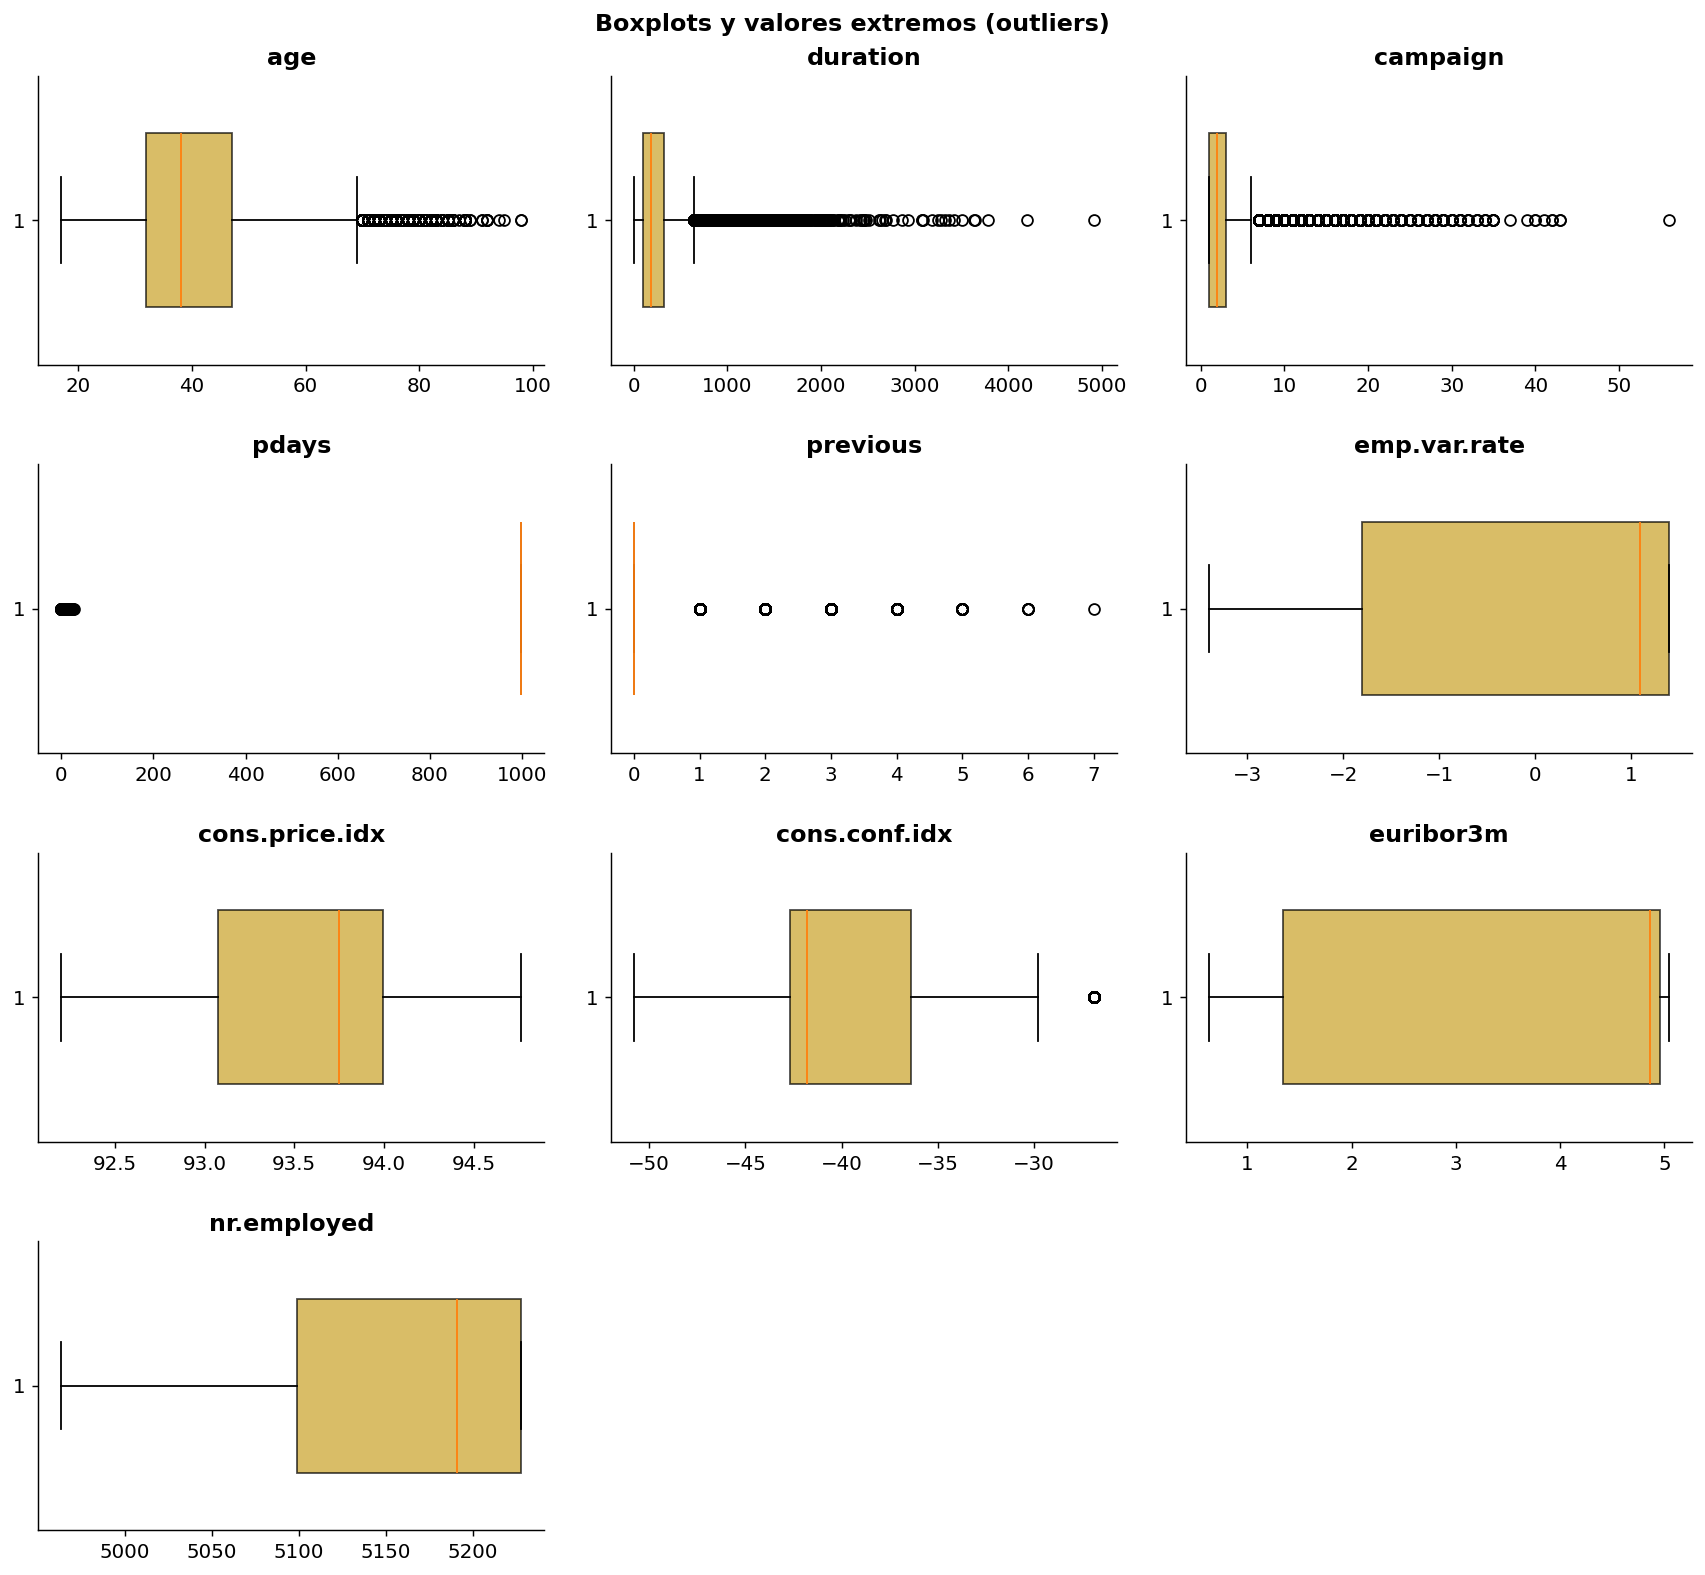

In [54]:
fig, axs = plt.subplots(4, 3, figsize=(13, 12), constrained_layout=True); axs = axs.ravel()
for k, c in enumerate(NUM_EDA):
    bp = axs[k].boxplot(df_raw[c].dropna(), vert=False, patch_artist=True, widths=0.6)
    bp['boxes'][0].set(facecolor=GOLD, alpha=0.7)
    axs[k].set_title(c)
for k in range(len(NUM_EDA), len(axs)): axs[k].axis('off')
fig.set_constrained_layout_pads(hspace=0.10, wspace=0.06)
fig.suptitle('Boxplots y valores extremos (outliers)', fontweight='bold')
plt.show()

In [49]:
filas = []
for c in NUM_EDA:
    q1, q3 = df_raw[c].quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = int(((df_raw[c] < lo) | (df_raw[c] > hi)).sum())
    filas.append({'variable': c, 'Q1': round(q1,2), 'Q3': round(q3,2), 'IQR': round(iqr,2),
                  'lim_inf': round(lo,2), 'lim_sup': round(hi,2),
                  'n_outliers': n, 'pct_outliers': round(n/len(df_raw)*100, 2)})
outliers_report = pd.DataFrame(filas).sort_values('pct_outliers', ascending=False).reset_index(drop=True)
outliers_report

,variable,Q1,Q3,IQR,lim_inf,lim_sup,n_outliers,pct_outliers
0,previous,0.00,0.00,0.00,0.00,0.00,5625,13.66
1,duration,102.00,319.00,217.00,-223.50,644.50,2963,7.19
2,campaign,1.00,3.00,2.00,-2.00,6.00,2406,5.84
3,pdays,999.00,999.00,0.00,999.00,999.00,1515,3.68
4,age,32.00,47.00,15.00,9.50,69.50,469,1.14
5,cons.conf.idx,-42.70,-36.40,6.30,-52.15,-26.95,447,1.09
6,emp.var.rate,-1.80,1.40,3.20,-6.60,6.20,0,0.00
7,cons.price.idx,93.08,93.99,0.92,91.70,95.37,0,0.00
8,euribor3m,1.34,4.96,3.62,-4.08,10.39,0,0.00
9,nr.employed,5099.10,5228.10,129.00,4905.60,5421.60,0,0.00


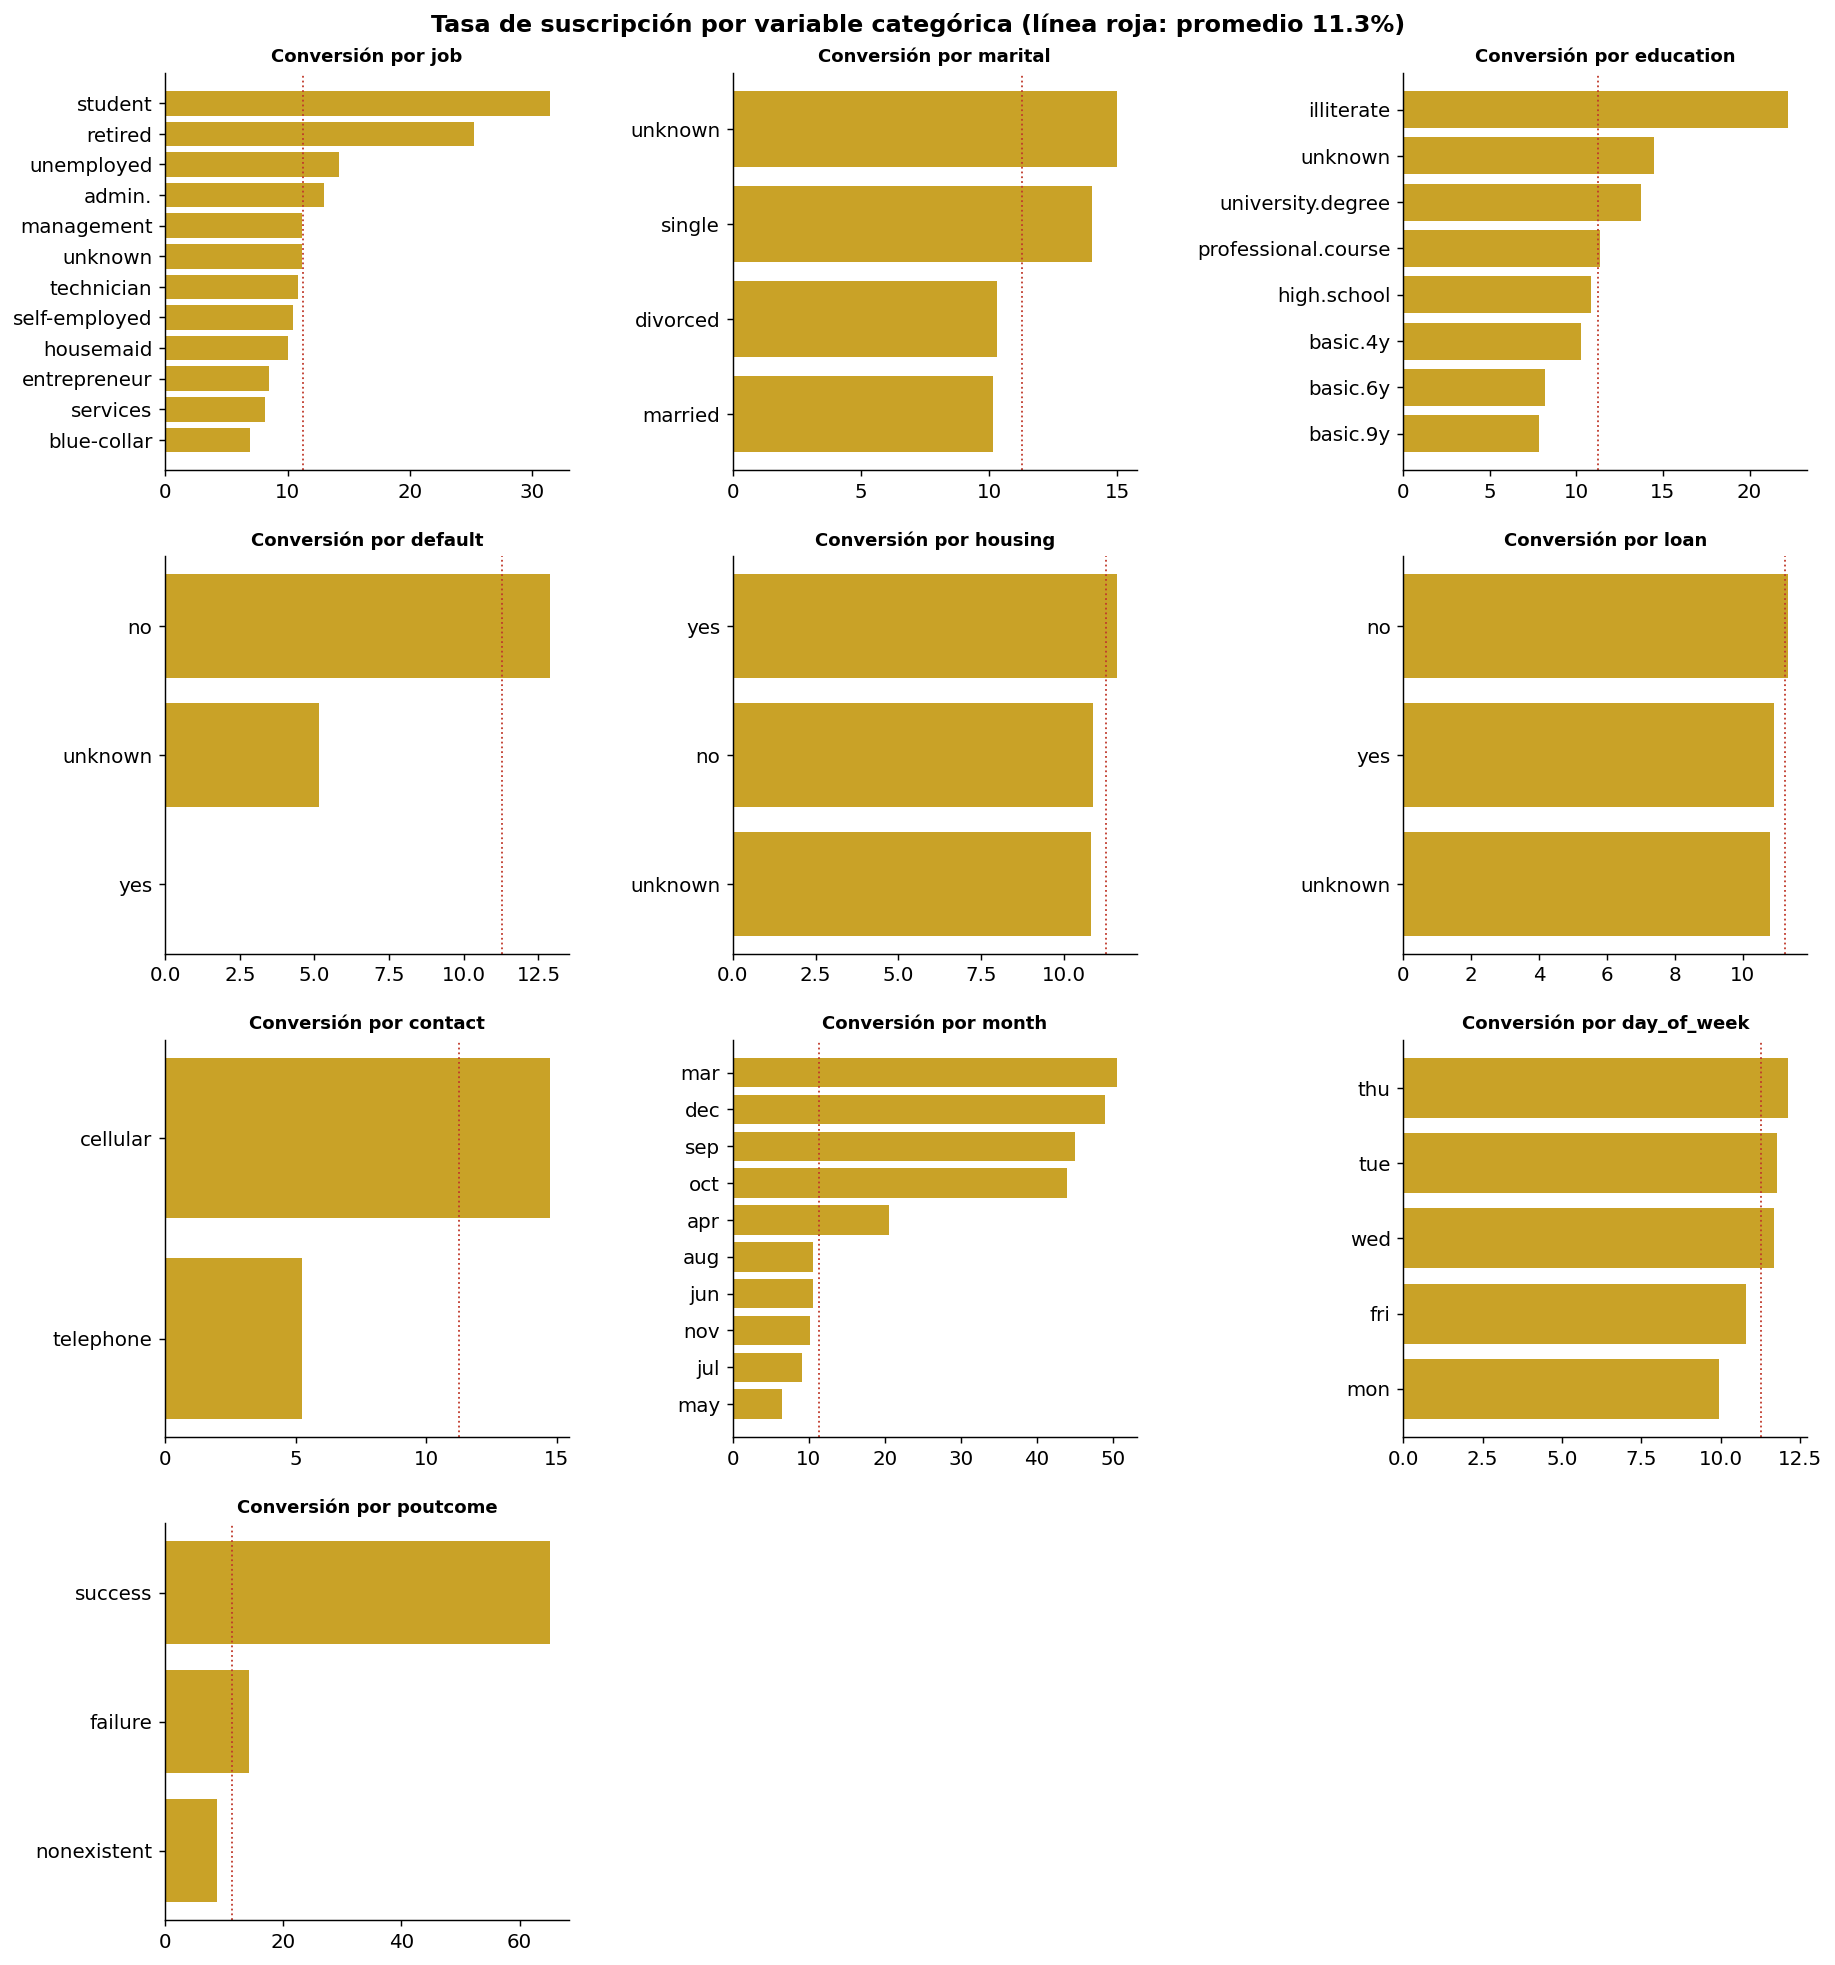

In [55]:
prom = (df_raw['y'] == 'yes').mean() * 100
fig, axs = plt.subplots(4, 3, figsize=(14, 15), constrained_layout=True); axs = axs.ravel()
for k, c in enumerate(CAT_EDA):
    t = df_raw.groupby(c)['y'].apply(lambda s: (s == 'yes').mean() * 100).sort_values()
    axs[k].barh(t.index.astype(str), t.values, color=GOLD)
    axs[k].axvline(prom, color=RED, ls=':', lw=1)
    axs[k].set_title(f'Conversión por {c}', fontsize=10)
for k in range(len(CAT_EDA), len(axs)): axs[k].axis('off')
fig.set_constrained_layout_pads(hspace=0.06, wspace=0.10)
fig.suptitle(f'Tasa de suscripción por variable categórica (línea roja: promedio {prom:.1f}%)', fontweight='bold')
plt.show()

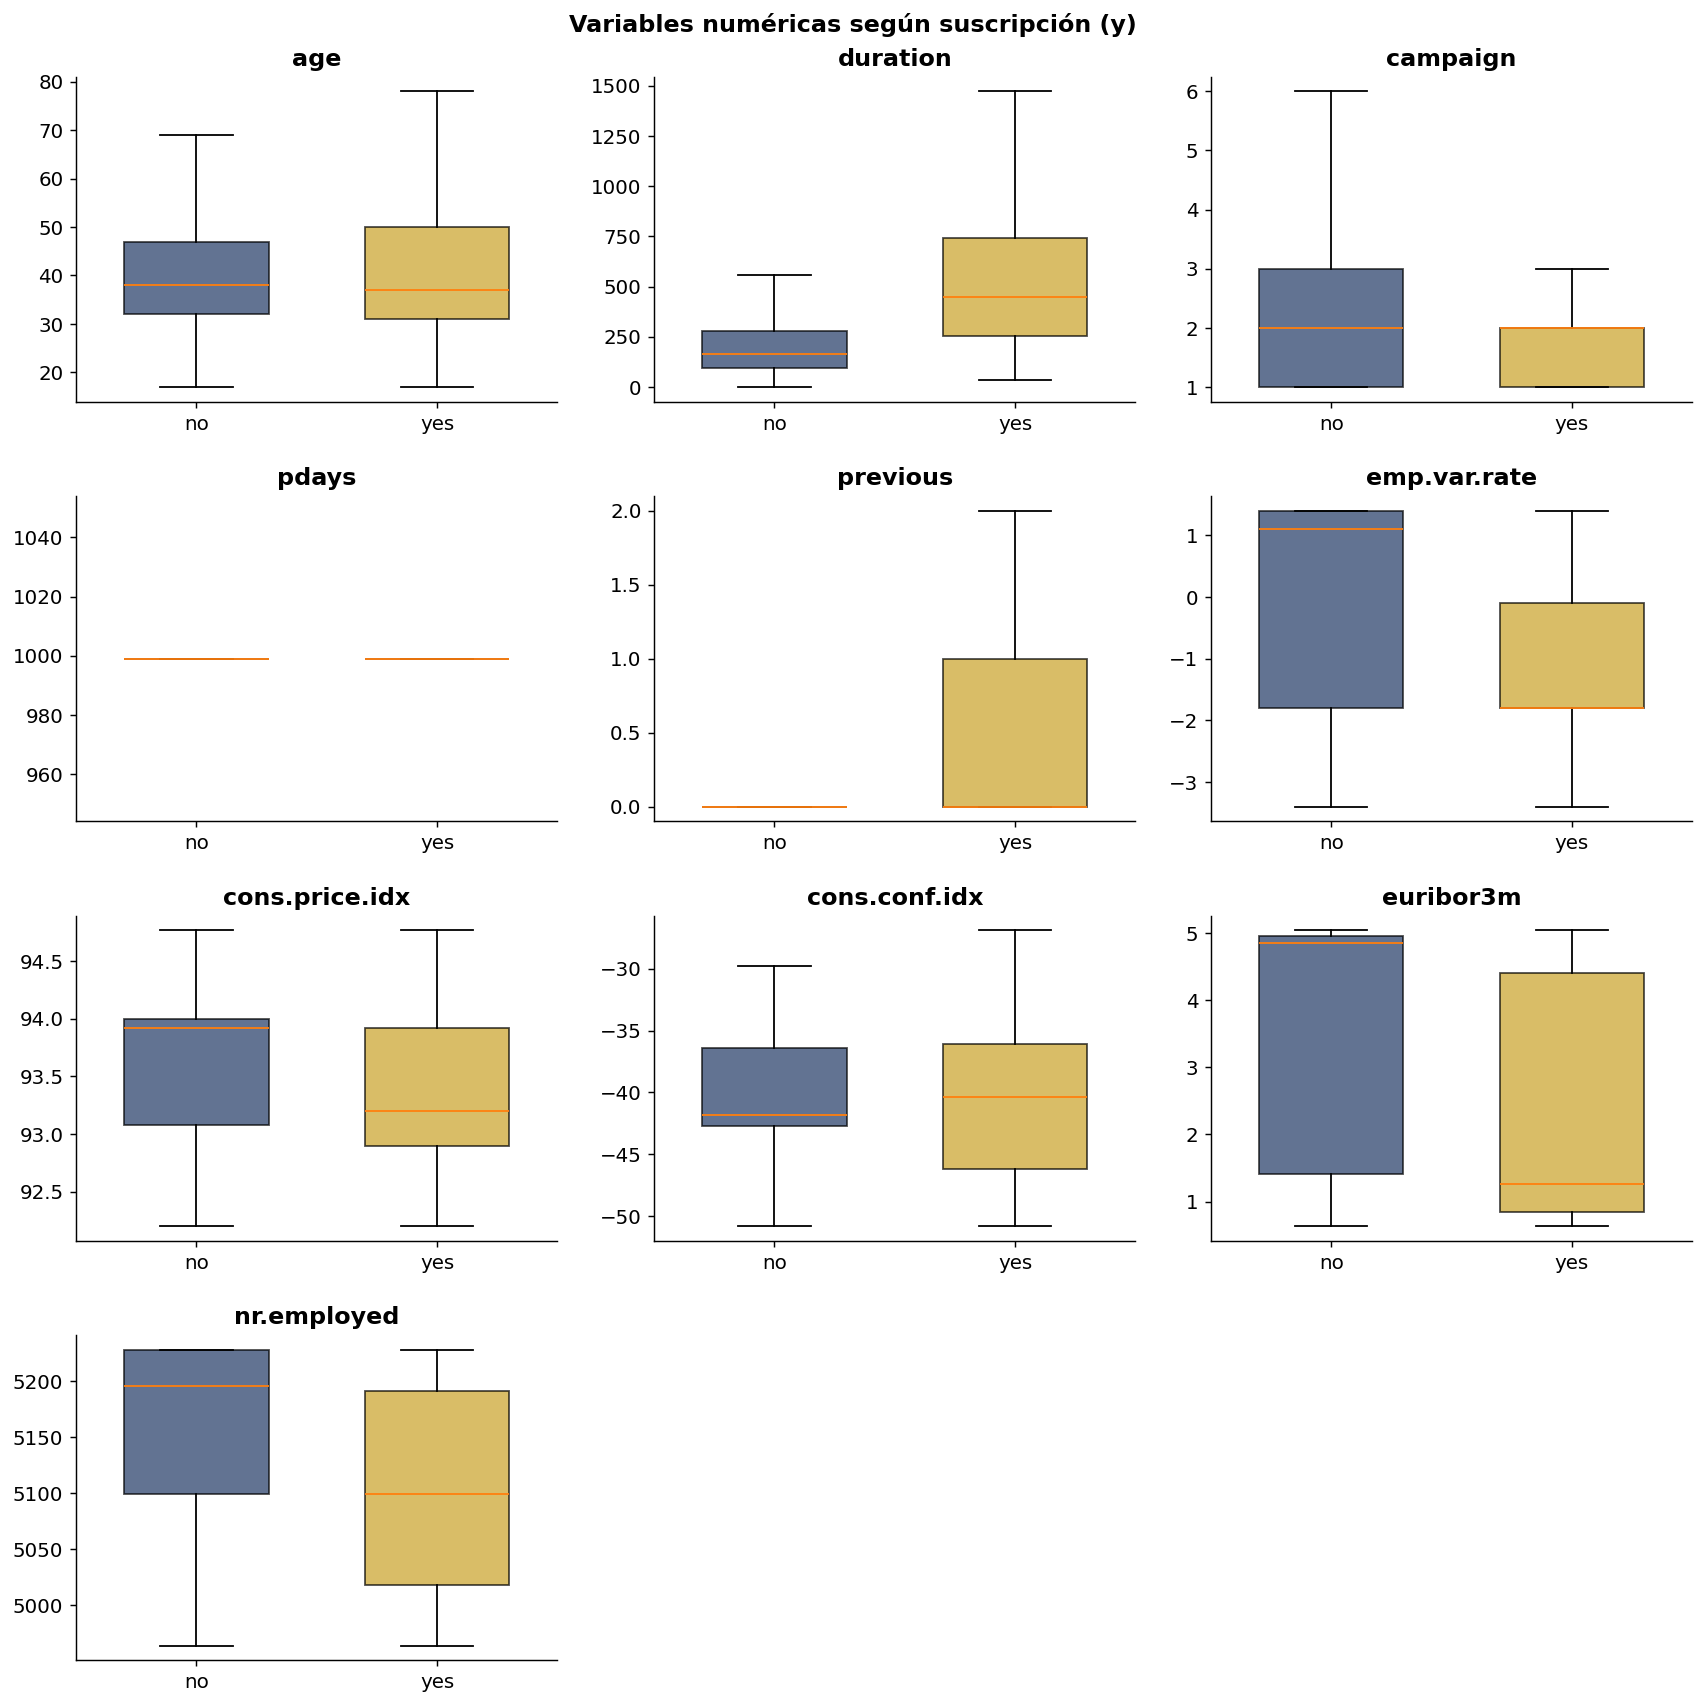

In [56]:
fig, axs = plt.subplots(4, 3, figsize=(13, 13), constrained_layout=True); axs = axs.ravel()
for k, c in enumerate(NUM_EDA):
    grupos = [df_raw.loc[df_raw['y'] == v, c].dropna() for v in ['no', 'yes']]
    bp = axs[k].boxplot(grupos, labels=['no', 'yes'], patch_artist=True, widths=0.6, showfliers=False)
    for box, col in zip(bp['boxes'], [NAVY, GOLD]): box.set(facecolor=col, alpha=0.7)
    axs[k].set_title(c)
for k in range(len(NUM_EDA), len(axs)): axs[k].axis('off')
fig.set_constrained_layout_pads(hspace=0.08, wspace=0.06)
fig.suptitle('Variables numéricas según suscripción (y)', fontweight='bold')
plt.show()

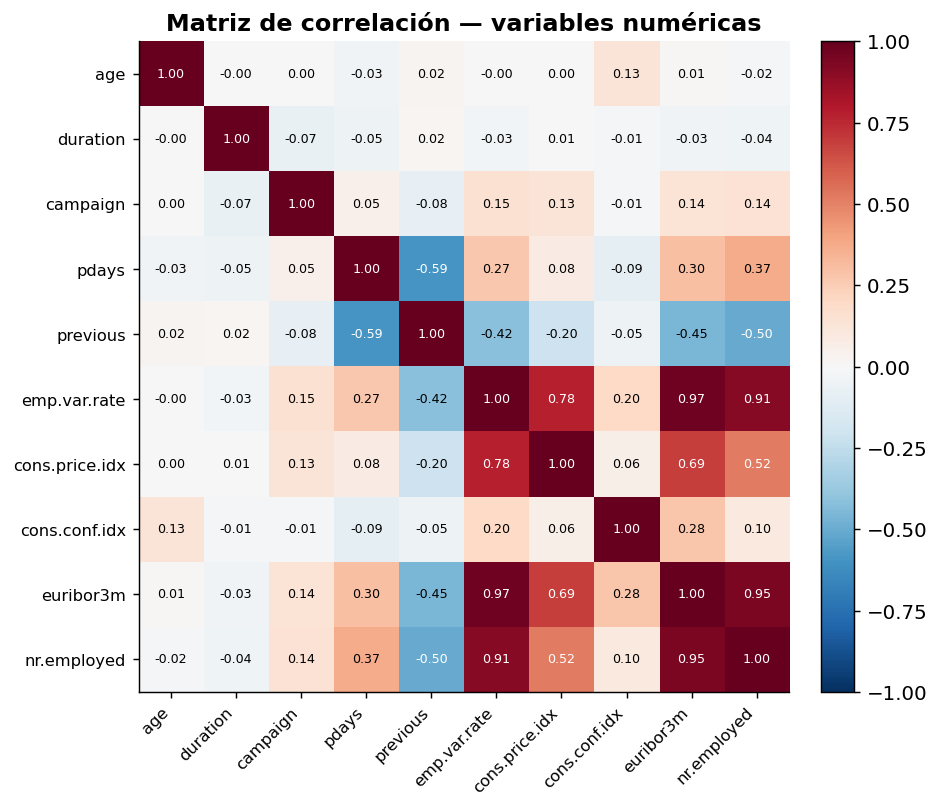

In [52]:
corr_num = df_raw[NUM_EDA].corr()
fig, ax = plt.subplots(figsize=(8, 6.5)); im = ax.imshow(corr_num, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(NUM_EDA))); ax.set_xticklabels(NUM_EDA, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(NUM_EDA))); ax.set_yticklabels(NUM_EDA, fontsize=9)
for i in range(len(NUM_EDA)):
    for j in range(len(NUM_EDA)):
        ax.text(j, i, f'{corr_num.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr_num.iloc[i,j])>0.5 else 'black')
ax.set_title('Matriz de correlación — variables numéricas')
plt.colorbar(im, fraction=0.046, pad=0.04)

## 3. Diagnóstico de calidad de datos

No hay nulos formales (NaN): True


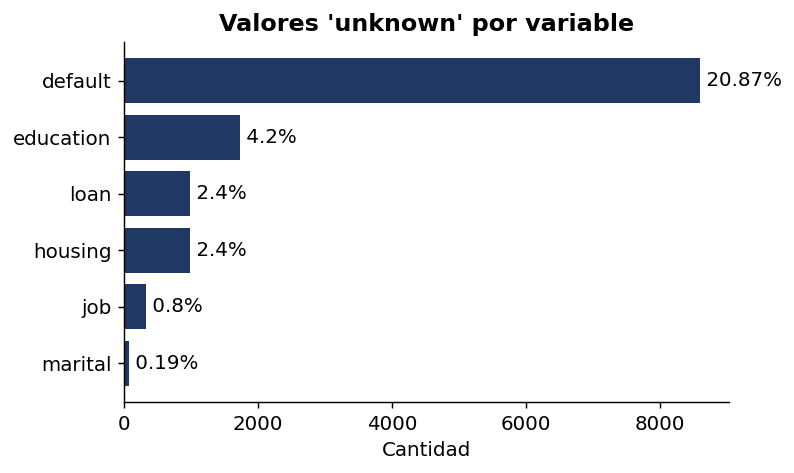

,variable,nulos,unknown,pct_unknown
0,default,0,8597,20.87
1,education,0,1731,4.20
2,housing,0,990,2.40
3,loan,0,990,2.40
4,job,0,330,0.80
5,marital,0,80,0.19
6,age,0,0,0.00
7,poutcome,0,0,0.00
8,nr.employed,0,0,0.00
9,euribor3m,0,0,0.00


In [ ]:
# ============================================================
# Valores 'unknown' y nulos
# ============================================================
rep = []
for col in df_raw.columns:
    unk = int((df_raw[col].astype(str).str.lower() == 'unknown').sum()) if df_raw[col].dtype == 'object' else 0
    rep.append({'variable': col, 'nulos': int(df_raw[col].isna().sum()),
                'unknown': unk, 'pct_unknown': round(unk/len(df_raw)*100, 2)})
unknown_report = pd.DataFrame(rep).sort_values('pct_unknown', ascending=False).reset_index(drop=True)
print('No hay nulos formales (NaN):', df_raw.isna().sum().sum() == 0)

plot = unknown_report[unknown_report['unknown'] > 0].sort_values('unknown')
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.barh(plot['variable'], plot['unknown'], color=NAVY)
for i, (v, p) in enumerate(zip(plot['unknown'], plot['pct_unknown'])):
    ax.text(v, i, f' {p}%', va='center')
ax.set_title("Valores 'unknown' por variable"); ax.set_xlabel('Cantidad')
guardar_fig('fig2_unknown'); plt.show()
unknown_report

In [11]:
# variable 'Default'

print('Distribución de default:')
print(df_raw['default'].value_counts().to_string())

Distribución de default:
default
no         32588
unknown     8597
yes            3


In [13]:
# Duplicados

dups = int(df_raw.duplicated().sum())
print(f'Registros duplicados exactos: {dups}')

Registros duplicados exactos: 12


In [15]:
# pdays

print(f"pdays == 999: {(df_raw['pdays']==999).sum():,} ({(df_raw['pdays']==999).mean()*100:.2f}%)")
print('999 NO es un valor real: codifica "cliente no contactado previamente".')
print('\nConsistencia pdays(=999) vs poutcome:')
print(pd.crosstab(df_raw['pdays']==999, df_raw['poutcome']))
print('\nprevious>0 vs pdays==999 (redundancia/solapamiento de información):')
print(pd.crosstab(df_raw['previous']==0, df_raw['pdays']==999,
                  rownames=['previous==0'], colnames=['pdays==999']))

pdays == 999: 39,673 (96.32%)
999 NO es un valor real: codifica "cliente no contactado previamente".

Consistencia pdays(=999) vs poutcome:
poutcome  failure  nonexistent  success
pdays                                  
False         142            0     1373
True         4110        35563        0

previous>0 vs pdays==999 (redundancia/solapamiento de información):
pdays==999   False  True 
previous==0              
False         1515   4110
True             0  35563


In [17]:
# duration

print('Duración media por clase (segundos):')
print(df_raw.groupby('y')['duration'].mean().round(1).to_string())
print(f"\nRegistros con duration == 0: {(df_raw['duration']==0).sum()} "
      f"-> y de esos: {df_raw.loc[df_raw['duration']==0,'y'].unique().tolist()}")

Duración media por clase (segundos):
y
no     220.8
yes    553.2

Registros con duration == 0: 4 -> y de esos: ['no']


## 4. Análisis inferencial

In [18]:
# Categóricas vs y

from scipy.stats import chi2_contingency

def cramers_v(conf):
    chi2 = chi2_contingency(conf)[0]
    n = conf.sum().sum()
    r, k = conf.shape
    return np.sqrt((chi2/n) / (min(r-1, k-1)))

cat_cols = ['job','marital','education','housing','loan','contact','month','day_of_week','poutcome']
res = []
for c in cat_cols:
    conf = pd.crosstab(df_raw[c], df_raw['y'])
    chi2, p, dof, _ = chi2_contingency(conf)
    res.append({'variable': c, 'chi2': round(chi2,1), 'p_value': p,
                'cramers_v': round(cramers_v(conf),3),
                'significativa_(p<0.05)': p < 0.05})
chi_tabla = pd.DataFrame(res).sort_values('cramers_v', ascending=False).reset_index(drop=True)
chi_tabla

,variable,chi2,p_value,cramers_v,significativa_(p<0.05)
0,poutcome,4230.5,0.000000e+00,0.320,True
1,month,3101.1,0.000000e+00,0.274,True
2,job,961.2,4.189763e-199,0.153,True
3,contact,862.3,1.525986e-189,0.145,True
4,education,193.1,3.305189e-38,0.068,True
5,marital,122.7,2.068015e-26,0.055,True
6,day_of_week,26.1,2.958482e-05,0.025,True
7,housing,5.7,5.829448e-02,0.012,False
8,loan,1.1,5.786753e-01,0.005,False


In [19]:

# Numéricas vs y

from scipy.stats import mannwhitneyu, ks_2samp

num_cols = ['age','duration','campaign','pdays','previous',
            'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
g_yes = df_raw[df_raw['y']=='yes']; g_no = df_raw[df_raw['y']=='no']
res = []
for c in num_cols:
    u, p_mw = mannwhitneyu(g_yes[c], g_no[c], alternative='two-sided')
    ks, p_ks = ks_2samp(g_yes[c], g_no[c])
    res.append({'variable': c,
                'media_yes': round(g_yes[c].mean(),2), 'media_no': round(g_no[c].mean(),2),
                'mannwhitney_p': p_mw, 'ks_stat': round(ks,3), 'ks_p': p_ks,
                'sig_(p<0.05)': (p_mw < 0.05)})
num_tabla = pd.DataFrame(res).sort_values('ks_stat', ascending=False).reset_index(drop=True)
num_tabla

,variable,media_yes,media_no,mannwhitney_p,ks_stat,ks_p,sig_(p<0.05)
0,duration,553.19,220.84,0.000000e+00,0.464,0.000000e+00,True
1,euribor3m,2.12,3.81,0.000000e+00,0.433,0.000000e+00,True
2,emp.var.rate,-1.23,0.25,0.000000e+00,0.432,0.000000e+00,True
3,nr.employed,5095.12,5176.17,0.000000e+00,0.432,0.000000e+00,True
4,cons.price.idx,93.35,93.60,9.572609e-136,0.228,9.808385e-189,True
5,previous,0.49,0.13,0.000000e+00,0.210,5.096083e-160,True
6,cons.conf.idx,-39.79,-40.59,5.901951e-17,0.200,1.357292e-144,True
7,pdays,792.04,984.11,0.000000e+00,0.193,2.223631e-135,True
8,age,40.91,39.91,1.608054e-02,0.086,5.397245e-27,True
9,campaign,2.05,2.63,3.418527e-38,0.081,7.605311e-24,True


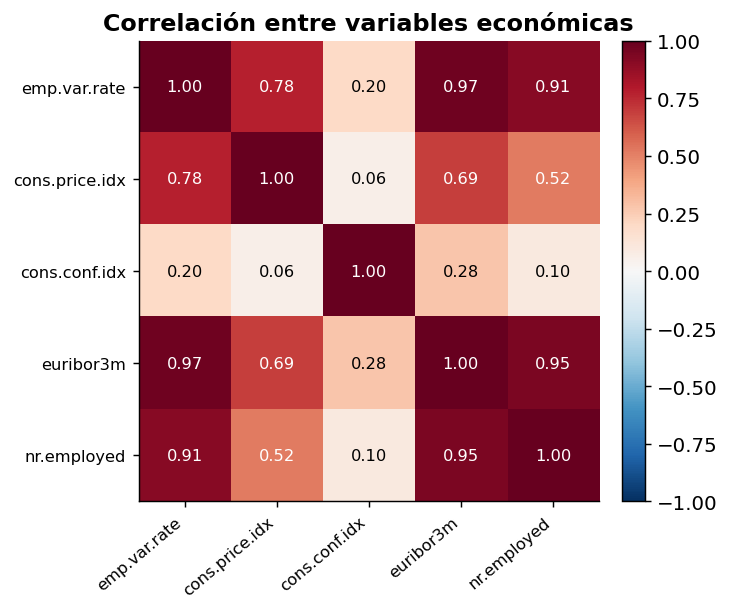

VIF:
emp.var.rate      32.90
cons.price.idx     6.30
cons.conf.idx      2.60
euribor3m         63.87
nr.employed       30.75


In [22]:
# Colinealidad de variables económicas

econ = ['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
corr = df_raw[econ].corr()

fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(econ))); ax.set_xticklabels(econ, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(econ))); ax.set_yticklabels(econ, fontsize=9)
for i in range(len(econ)):
    for j in range(len(econ)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(corr.iloc[i,j])>0.5 else 'black')
ax.set_title('Correlación entre variables económicas')
plt.colorbar(im, fraction=0.046, pad=0.04)
guardar_fig('fig3_colinealidad'); plt.show()

# VIF
vif = pd.Series(np.diag(np.linalg.inv(corr.values)), index=econ).round(2)
print('VIF:')
print(vif.to_string())

### 4.4 Tasas de conversión por variables categóricas

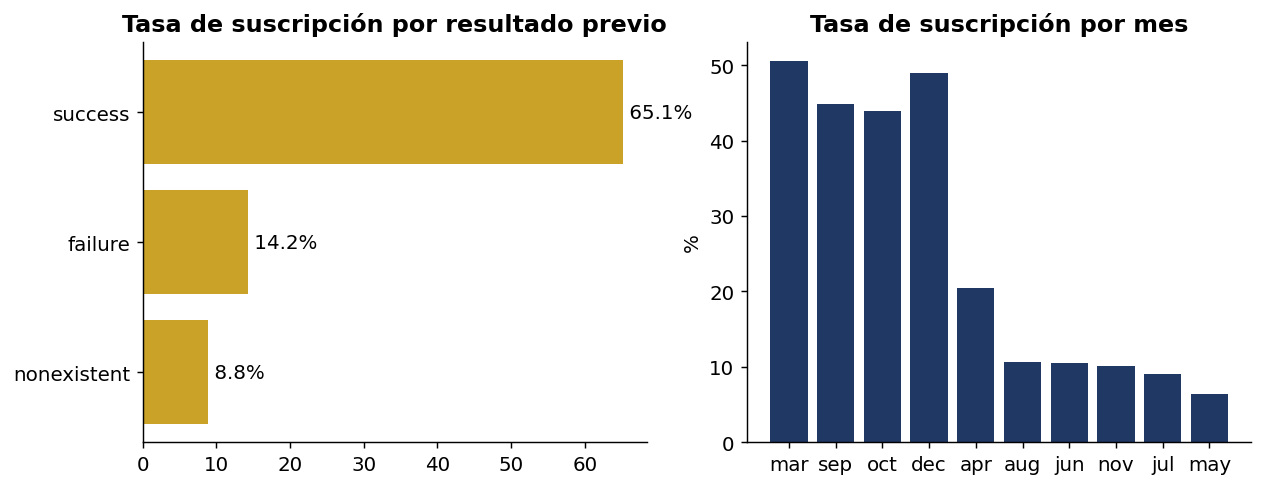

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
po = df_raw.groupby('poutcome')['y'].apply(lambda s: (s == 'yes').mean()*100).sort_values()
axs[0].barh(po.index, po.values, color=GOLD)
for i, v in enumerate(po.values): axs[0].text(v, i, f' {v:.1f}%', va='center')
axs[0].set_title('Tasa de suscripción por resultado previo')
orden = ['mar','sep','oct','dec','apr','aug','jun','nov','jul','may']
orden = [m for m in orden if m in df_raw['month'].unique()]
mo = df_raw.groupby('month')['y'].apply(lambda s: (s == 'yes').mean()*100).reindex(orden)
axs[1].bar(mo.index, mo.values, color=NAVY); axs[1].set_ylabel('%')
axs[1].set_title('Tasa de suscripción por mes')
guardar_fig('fig4_eda'); plt.show()

## 5. Preprocesamiento sin fuga de información

In [24]:
# Limpieza base y construcción de los dos escenarios de features

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

def preparar_base(df_in):
    d = df_in.drop_duplicates().reset_index(drop=True)
    d['contacted_prev'] = (d['pdays'] != 999).astype(int)
    d = d.drop(columns=['default', 'pdays'])
    return d

df = preparar_base(df_raw)
y = (df['y'] == 'yes').astype(int)
print('Tras limpieza:', df.shape, '| positivos:', int(y.sum()), f'({y.mean()*100:.2f}%)')

NUM_BASE = ['age','campaign','previous','emp.var.rate','cons.price.idx',
            'cons.conf.idx','euribor3m','nr.employed','contacted_prev']
CAT_BASE = ['job','marital','education','housing','loan','contact','month','day_of_week','poutcome']

def features(con_duration: bool):
    num = NUM_BASE + (['duration'] if con_duration else [])
    return num, CAT_BASE

def preprocesador(num, cat, escalar: bool):
    '''escalar=True para LR/LinearSVC; False para árboles.'''
    num_t = StandardScaler() if escalar else 'passthrough'
    return ColumnTransformer([
        ('num', num_t, num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat),
    ])

print('Escenario realista (sin duration):', len(features(False)[0]), 'num +', len(features(False)[1]), 'cat')
print('Escenario benchmark (con duration):', len(features(True)[0]), 'num +', len(features(True)[1]), 'cat')

Tras limpieza: (41176, 20) | positivos: 4639 (11.27%)
Escenario realista (sin duration): 9 num + 9 cat
Escenario benchmark (con duration): 10 num + 9 cat


## 6. Estrategia de validación

In [25]:
# Particiones

from sklearn.model_selection import train_test_split, StratifiedKFold

# Datos completos por escenario
def Xy(con_duration):
    num, cat = features(con_duration)
    return df[num + cat], y

X_real, _ = Xy(False)
X_bench, _ = Xy(True)
Xtr_r, Xte_r, ytr, yte = train_test_split(X_real, y, test_size=0.25,
                                           stratify=y, random_state=RANDOM_STATE)
Xtr_b, Xte_b = X_bench.loc[Xtr_r.index], X_bench.loc[Xte_r.index]

corte = int(len(X_real) * 0.75)
Xtr_t, Xte_t = X_real.iloc[:corte], X_real.iloc[corte:]
ytr_t, yte_t = y.iloc[:corte], y.iloc[corte:]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
spw = (ytr == 0).sum() / (ytr == 1).sum()   # scale_pos_weight para XGB
print(f'Train: {len(Xtr_r):,} | Test: {len(Xte_r):,} | scale_pos_weight={spw:.2f}')

Train: 30,882 | Test: 10,294 | scale_pos_weight=7.88


## 7. Modelado: pool de candidatos, tuning y stacking

In [26]:
# Definición de modelos

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier

def construir_modelos(con_duration):
    num, cat = features(con_duration)
    pre_s  = lambda: preprocesador(num, cat, escalar=True)
    pre_ns = lambda: preprocesador(num, cat, escalar=False)
    return {
        'LR': Pipeline([('pre', pre_s()),
                        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                                   random_state=RANDOM_STATE))]),
        'LinearSVC': Pipeline([('pre', pre_s()),
                        ('clf', CalibratedClassifierCV(
                            LinearSVC(class_weight='balanced', dual='auto',
                                      random_state=RANDOM_STATE), cv=3))]),
        'RandomForest': Pipeline([('pre', pre_ns()),
                        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                       n_jobs=-1, random_state=RANDOM_STATE))]),
        'XGBoost': Pipeline([('pre', pre_ns()),
                        ('clf', XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.1,
                                              subsample=0.9, colsample_bytree=0.9,
                                              scale_pos_weight=spw, eval_metric='logloss',
                                              random_state=RANDOM_STATE, n_jobs=-1))]),
    }

modelos_real = construir_modelos(False)
print('Modelos definidos (escenario realista):', list(modelos_real))

Modelos definidos (escenario realista): ['LR', 'LinearSVC', 'RandomForest', 'XGBoost']


In [27]:
# 7.2 Tuning de RF y XGB

from sklearn.model_selection import RandomizedSearchCV

espacios = {
    'RandomForest': {
        'clf__n_estimators': [200, 400, 600],
        'clf__max_depth': [None, 8, 12, 20],
        'clf__min_samples_leaf': [1, 5, 20],
        'clf__max_features': ['sqrt', 'log2', 0.5],
    },
    'XGBoost': {
        'clf__n_estimators': [200, 400, 600],
        'clf__max_depth': [3, 4, 6, 8],
        'clf__learning_rate': [0.03, 0.05, 0.1],
        'clf__subsample': [0.7, 0.9, 1.0],
        'clf__colsample_bytree': [0.7, 0.9, 1.0],
        'clf__min_child_weight': [1, 3, 5],
    },
}

def tunear(modelos, n_iter=20):
    afinados = dict(modelos)
    for nombre, espacio in espacios.items():
        print(f'Tuning {nombre} ...', end=' ')
        rs = RandomizedSearchCV(modelos[nombre], espacio, n_iter=n_iter,
                                scoring='average_precision', cv=cv,
                                random_state=RANDOM_STATE, n_jobs=-1, refit=True)
        rs.fit(Xtr_r, ytr)
        afinados[nombre] = rs.best_estimator_
        print(f'PR-AUC(cv)={rs.best_score_:.3f}')
    return afinados

modelos_real = tunear(modelos_real, n_iter=20)

Tuning RandomForest ... PR-AUC(cv)=0.466
Tuning XGBoost ... PR-AUC(cv)=0.463


In [28]:
# Ensemble por stacking (meta-modelo logístico)

stack_real = StackingClassifier(
    estimators=[('lr', modelos_real['LR']),
                ('rf', modelos_real['RandomForest']),
                ('xgb', modelos_real['XGBoost'])],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    stack_method='predict_proba', cv=5, n_jobs=-1)

modelos_real['Stacking'] = stack_real
print('Ajustando todos los modelos del escenario realista...')
for nombre, m in modelos_real.items():
    m.fit(Xtr_r, ytr)
    print(' -', nombre, 'OK')

Ajustando todos los modelos del escenario realista...
 - LR OK
 - LinearSVC OK
 - RandomForest OK
 - XGBoost OK
 - Stacking OK


## 8. Evaluación comparativa

In [29]:
# Funciones de evaluación

from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score, confusion_matrix,
    brier_score_loss)
from scipy.stats import ks_2samp

def ks_score(y_true, p):
    return ks_2samp(p[y_true == 1], p[y_true == 0]).statistic

def evaluar(modelos, Xte, yte, umbral=0.5):
    filas = []
    for nombre, m in modelos.items():
        p = m.predict_proba(Xte)[:, 1]
        pred = (p >= umbral).astype(int)
        filas.append({
            'modelo': nombre,
            'PR_AUC': round(average_precision_score(yte, p), 4),
            'ROC_AUC': round(roc_auc_score(yte, p), 4),
            'KS': round(ks_score(yte.values, p), 4),
            'F1': round(f1_score(yte, pred), 4),
            'Precision': round(precision_score(yte, pred), 4),
            'Recall': round(recall_score(yte, pred), 4),
            'Accuracy': round(accuracy_score(yte, pred), 4),
            'Brier': round(brier_score_loss(yte, p), 4),
        })
    return pd.DataFrame(filas).sort_values('PR_AUC', ascending=False).reset_index(drop=True)

tabla_real = evaluar(modelos_real, Xte_r, yte)
print('=== Escenario REALISTA (sin duration) ==='); print(tabla_real.to_string(index=False))

=== Escenario REALISTA (sin duration) ===
      modelo  PR_AUC  ROC_AUC     KS     F1  Precision  Recall  Accuracy  Brier
RandomForest  0.4940   0.8132 0.5281 0.5044     0.4183  0.6353    0.8593 0.1362
    Stacking  0.4901   0.8139 0.5259 0.3746     0.6566  0.2621    0.9014 0.0754
     XGBoost  0.4786   0.8094 0.5230 0.4780     0.3777  0.6509    0.8398 0.1530
          LR  0.4429   0.8014 0.5027 0.4637     0.3639  0.6388    0.8335 0.1621
   LinearSVC  0.4392   0.8015 0.5032 0.3131     0.6434  0.2069    0.8977 0.0787


In [30]:
# 8.2 Escenario benchmark CON duration

modelos_bench = construir_modelos(True)
modelos_bench = {k: v for k, v in modelos_bench.items()}  # sin tuning extra para agilizar
modelos_bench['Stacking'] = StackingClassifier(
    estimators=[('lr', modelos_bench['LR']),
                ('rf', modelos_bench['RandomForest']),
                ('xgb', modelos_bench['XGBoost'])],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    stack_method='predict_proba', cv=5, n_jobs=-1)
for m in modelos_bench.values():
    m.fit(Xtr_b, ytr)

tabla_bench = evaluar(modelos_bench, Xte_b, yte)
print('=== Escenario BENCHMARK (con duration) ==='); print(tabla_bench.to_string(index=False))
print('\n-> La caída de PR-AUC/KS al quitar duration cuantifica cuánta "señal" venía')
print('   de una variable no disponible en producción. El modelo válido es el realista.')

=== Escenario BENCHMARK (con duration) ===
      modelo  PR_AUC  ROC_AUC     KS     F1  Precision  Recall  Accuracy  Brier
    Stacking  0.6679   0.9504 0.7983 0.6299     0.6289  0.6310    0.9165 0.0555
     XGBoost  0.6524   0.9492 0.7947 0.6299     0.4811  0.9121    0.8793 0.0854
RandomForest  0.6480   0.9447 0.7900 0.5149     0.6722  0.4172    0.9114 0.0579
   LinearSVC  0.5848   0.9391 0.7732 0.4982     0.6401  0.4078    0.9074 0.0635
          LR  0.5839   0.9394 0.7776 0.5972     0.4460  0.9034    0.8626 0.1014

-> La caída de PR-AUC/KS al quitar duration cuantifica cuánta "señal" venía
   de una variable no disponible en producción. El modelo válido es el realista.


In [31]:
# Control de fuga temporal

xgb_temporal = construir_modelos(False)['XGBoost']
xgb_temporal.fit(Xtr_t, ytr_t)
p_temp = xgb_temporal.predict_proba(Xte_t)[:, 1]
print('XGBoost — comparación de protocolos (escenario realista):')
print(f"  Split estratificado : PR-AUC={tabla_real.loc[tabla_real['modelo']=='XGBoost','PR_AUC'].values[0]:.3f}")
print(f"  Holdout temporal    : PR-AUC={average_precision_score(yte_t, p_temp):.3f} | "
      f"ROC={roc_auc_score(yte_t, p_temp):.3f} | KS={ks_score(yte_t.values, p_temp):.3f}")
print('\n-> Una diferencia notable confirma sensibilidad al ordenamiento temporal')
print('   (variables económicas como proxy del tiempo). Se reporta como limitación.')

XGBoost — comparación de protocolos (escenario realista):
  Split estratificado : PR-AUC=0.479
  Holdout temporal    : PR-AUC=0.358 | ROC=0.588 | KS=0.143

-> Una diferencia notable confirma sensibilidad al ordenamiento temporal
   (variables económicas como proxy del tiempo). Se reporta como limitación.


Mejor modelo (PR-AUC): RandomForest


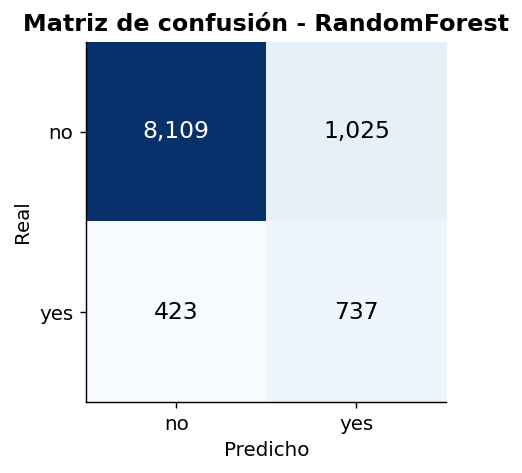

In [32]:
# Matriz de confusión

from sklearn.calibration import calibration_curve

mejor_nombre = tabla_real.iloc[0]['modelo']
mejor = modelos_real[mejor_nombre]
p_best = mejor.predict_proba(Xte_r)[:, 1]
print('Mejor modelo (PR-AUC):', mejor_nombre)

cm = confusion_matrix(yte, (p_best >= 0.5).astype(int))
fig, ax = plt.subplots(figsize=(4, 3.6)); im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=13,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_xticks([0,1]); ax.set_xticklabels(['no','yes']); ax.set_xlabel('Predicho')
ax.set_yticks([0,1]); ax.set_yticklabels(['no','yes']); ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusión - {mejor_nombre}')
guardar_fig('fig6_confusion'); plt.show()

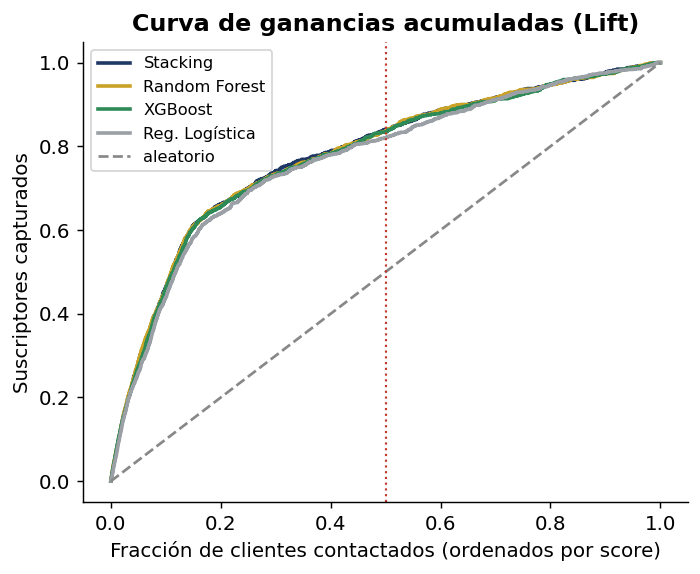

Contactando al 20% mejor rankeado se captura el 65.8% de los suscriptores.
Contactando al 50% mejor rankeado se captura el 83.7% de los suscriptores.


In [34]:
# Curva de ganancias acumuladas
colores = {'Stacking': NAVY, 'RandomForest': GOLD, 'XGBoost': GREEN, 'LR': GREY}
nombres = {'Stacking':'Stacking','RandomForest':'Random Forest','XGBoost':'XGBoost','LR':'Reg. Logística'}
fig, ax = plt.subplots(figsize=(6, 4.6))
for n in ['Stacking', 'RandomForest', 'XGBoost', 'LR']:
    if n in modelos_real:
        p = modelos_real[n].predict_proba(Xte_r)[:, 1]
        d = pd.DataFrame({'y': yte.values, 'p': p}).sort_values('p', ascending=False)
        ax.plot(np.arange(1, len(d)+1)/len(d), d['y'].cumsum()/d['y'].sum(),
                label=nombres[n], color=colores[n], lw=2)
ax.plot([0,1], [0,1], '--', color='#888', label='aleatorio')
ax.axvline(0.5, color=RED, ls=':', lw=1.2)
ax.set_xlabel('Fracción de clientes contactados (ordenados por score)')
ax.set_ylabel('Suscriptores capturados')
ax.set_title('Curva de ganancias acumuladas (Lift)'); ax.legend(fontsize=9)
guardar_fig('fig5_lift'); plt.show()

d = pd.DataFrame({'y': yte.values, 'p': p_best}).sort_values('p', ascending=False)
for frac in [0.2, 0.5]:
    n = int(len(d)*frac); capt = d.head(n)['y'].sum() / d['y'].sum()
    print(f'Contactando al {int(frac*100)}% mejor rankeado se captura el {capt*100:.1f}% de los suscriptores.')

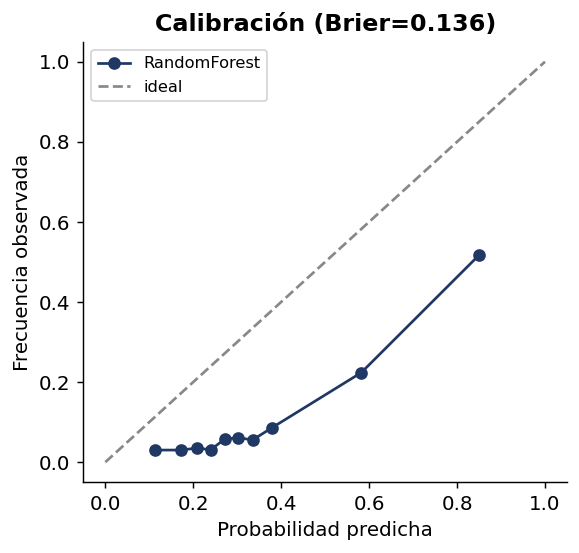

In [35]:
# Calibración del mejor modelo
frac_pos, mean_pred = calibration_curve(yte, p_best, n_bins=10, strategy='quantile')
fig, ax = plt.subplots(figsize=(4.8, 4.4))
ax.plot(mean_pred, frac_pos, 'o-', color=NAVY, label=mejor_nombre)
ax.plot([0,1], [0,1], '--', color='#888', label='ideal')
ax.set_xlabel('Probabilidad predicha'); ax.set_ylabel('Frecuencia observada')
ax.set_title(f'Calibración (Brier={brier_score_loss(yte,p_best):.3f})'); ax.legend(fontsize=9)
guardar_fig('fig7_calibracion'); plt.show()

## 9. Comparación estadística entre modelos

In [36]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from scipy.stats import mannwhitneyu

rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
scores = {}
for nombre in ['LR', 'LinearSVC', 'RandomForest', 'XGBoost']:
    s = cross_val_score(modelos_real[nombre], Xtr_r, ytr,
                        scoring='average_precision', cv=rcv, n_jobs=-1)
    scores[nombre] = s
    print(f'{nombre:13s} PR-AUC = {s.mean():.4f} ± {s.std():.4f}')

mejor_indiv = max(scores, key=lambda k: scores[k].mean())
print(f'\nPrueba pareada (Mann-Whitney) de {mejor_indiv} vs el resto:')
for nombre, s in scores.items():
    if nombre == mejor_indiv: continue
    _, p = mannwhitneyu(scores[mejor_indiv], s, alternative='greater')
    print(f'  {mejor_indiv} > {nombre}: p={p:.4f} '
          f'{"(significativo)" if p < 0.05 else "(no significativo)"}')

LR            PR-AUC = 0.4472 ± 0.0129
LinearSVC     PR-AUC = 0.4423 ± 0.0131
RandomForest  PR-AUC = 0.4658 ± 0.0129
XGBoost       PR-AUC = 0.4626 ± 0.0143

Prueba pareada (Mann-Whitney) de RandomForest vs el resto:
  RandomForest > LR: p=0.0005 (significativo)
  RandomForest > LinearSVC: p=0.0001 (significativo)
  RandomForest > XGBoost: p=0.2669 (no significativo)


## 10. Ajuste de umbral con lectura de negocio

Umbral óptimo (máx F1 en CV): 0.681
En test con umbral 0.681: Precision=0.492 Recall=0.551 F1=0.520


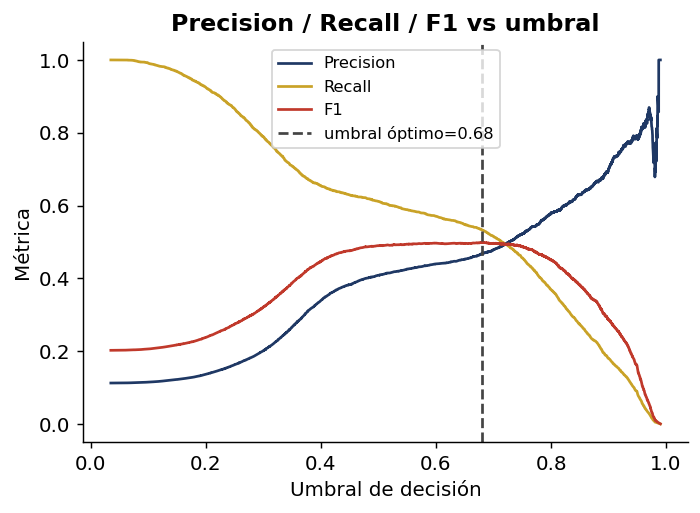

In [37]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

p_cv = cross_val_predict(mejor, Xtr_r, ytr, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(ytr, p_cv)
f1s = 2*prec*rec / (prec+rec+1e-12)
umbral_opt = thr[np.argmax(f1s[:-1])]
print(f'Umbral óptimo (máx F1 en CV): {umbral_opt:.3f}')

pred_opt = (p_best >= umbral_opt).astype(int)
print(f'En test con umbral {umbral_opt:.3f}: '
      f'Precision={precision_score(yte,pred_opt):.3f} '
      f'Recall={recall_score(yte,pred_opt):.3f} '
      f'F1={f1_score(yte,pred_opt):.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thr, prec[:-1], label='Precision', color=NAVY)
ax.plot(thr, rec[:-1], label='Recall', color=GOLD)
ax.plot(thr, f1s[:-1], label='F1', color=RED)
ax.axvline(umbral_opt, color='#444', ls='--', label=f'umbral óptimo={umbral_opt:.2f}')
ax.set_xlabel('Umbral de decisión'); ax.set_ylabel('Métrica'); ax.legend(fontsize=9)
ax.set_title('Precision / Recall / F1 vs umbral')
guardar_fig('fig9_umbral'); plt.show()

## 11. Interpretabilidad

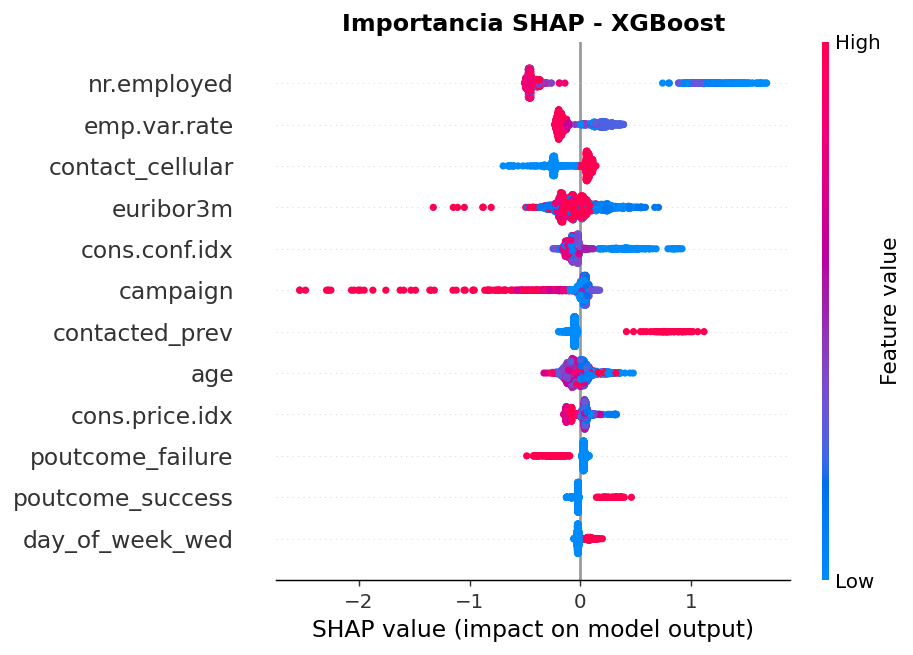

In [38]:
import shap

xgb_pipe = modelos_real['XGBoost']
pre = xgb_pipe.named_steps['pre']
clf = xgb_pipe.named_steps['clf']
feat_names = [f.replace('num__','').replace('cat__','') for f in pre.get_feature_names_out()]

X_shap = Xte_r.sample(min(2000, len(Xte_r)), random_state=RANDOM_STATE)
X_shap_t = pre.transform(X_shap)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap_t)

shap.summary_plot(shap_values, X_shap_t, feature_names=feat_names, show=False, max_display=12, color_bar=True)
fig = plt.gcf(); fig.set_size_inches(7, 4.8)
plt.title('Importancia SHAP - XGBoost', fontweight='bold')
guardar_fig('fig8_shap'); plt.show()

In [39]:
imp = pd.DataFrame({'feature': feat_names,
                    'shap_abs_mean': np.abs(shap_values).mean(axis=0)}) \
        .sort_values('shap_abs_mean', ascending=False).head(15).reset_index(drop=True)
print(imp.to_string(index=False))

                      feature  shap_abs_mean
                  nr.employed       0.536739
                 emp.var.rate       0.185312
             contact_cellular       0.136817
                    euribor3m       0.135574
                cons.conf.idx       0.099931
                     campaign       0.092308
               contacted_prev       0.085688
                          age       0.076153
               cons.price.idx       0.064201
             poutcome_failure       0.053510
             poutcome_success       0.035636
              day_of_week_wed       0.034560
              day_of_week_mon       0.033301
                     previous       0.027123
education_professional.course       0.022544


In [40]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(mejor, Xte_r, yte, scoring='average_precision',
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_tabla = pd.DataFrame({'variable': Xte_r.columns,
                           'importancia': perm.importances_mean,
                           'std': perm.importances_std}) \
               .sort_values('importancia', ascending=False).reset_index(drop=True)
perm_tabla.head(15)

,variable,importancia,std
0,nr.employed,0.149113,0.005521
1,euribor3m,0.053934,0.004520
2,contacted_prev,0.044719,0.005057
3,emp.var.rate,0.032142,0.005533
4,contact,0.024680,0.002286
5,month,0.012605,0.001899
6,poutcome,0.012218,0.003268
7,day_of_week,0.012127,0.001739
8,cons.conf.idx,0.009341,0.002186
9,campaign,0.008764,0.001902


In [41]:
lr_pipe = modelos_real['LR']
lr_feats = lr_pipe.named_steps['pre'].get_feature_names_out()
coefs = pd.DataFrame({'feature': lr_feats,
                      'coef': lr_pipe.named_steps['clf'].coef_[0]})
coefs['abs'] = coefs['coef'].abs()
print('Top +10 (empujan a suscribir):')
print(coefs.sort_values('coef', ascending=False).head(10)[['feature','coef']].to_string(index=False))
print('\nTop -10 (empujan a NO suscribir):')
print(coefs.sort_values('coef').head(10)[['feature','coef']].to_string(index=False))

Top +10 (empujan a suscribir):
                  feature     coef
           cat__month_mar 1.241261
      num__cons.price.idx 1.008723
           num__euribor3m 0.569880
           cat__month_dec 0.455846
           cat__month_aug 0.414828
         cat__job_retired 0.366328
    cat__poutcome_success 0.325687
    cat__contact_cellular 0.301991
cat__education_illiterate 0.300991
     cat__marital_unknown 0.288717

Top -10 (empujan a NO suscribir):
                           feature      coef
                 num__emp.var.rate -2.152578
                    cat__month_jun -0.724518
                    cat__month_may -0.644870
                    cat__month_nov -0.566426
             cat__poutcome_failure -0.361251
            cat__contact_telephone -0.320224
                    cat__month_apr -0.198346
               cat__job_unemployed -0.179564
             cat__marital_divorced -0.170737
cat__education_professional.course -0.146000
